In [1]:
# %pip install light-curve
%pip install nested-pandas --upgrade
%pip install lsdb --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 15.2 MB/s  0:00:00m0:00:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:━━━━━━━━━━━━━━━━━━ 0/2 [pandas]
      Successfully uninstalled pandas-2.3.3━━━━━ 0/2 [pandas]
  Attempting uninstall: nested-pandas━━━━━━━━━━━ 0/2 [pandas]
    Found existing installation: nested-pandas 0.6.10━━━━━━━━━━━━━ 1/2 [nested-pandas]
    Uninstalling nested-pandas-0.6.10:━━━━━━━━━━━━━━━━━━━ 1/2 [nested-pandas]
      Successfully uninstalled nested-pandas-0.6.10━━━━━━━━━━━ 1/2 [nested-pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nested-pandas]0m [nested-pandas]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hats 0.9.2 requires nested-pandas<0.7.0,>=0.6.7, but you have nested-pandas 0.7.0 which is incompatible.
lsdb 0.9.2 requires nested-pandas<0.7.0,>=0

In [2]:
import lsdb
import numpy as np
import matplotlib.pyplot as plt
from dask.distributed import Client
import light_curve as licu
import pyarrow as pa
from nested_pandas.utils import count_nested
from nested_pandas import read_parquet
from lsdb.core.search.region_search import MOCSearch

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DDF = True
DESI = False

In [4]:
lsdb.__version__

'0.9.2'

In [5]:
import nested_pandas
nested_pandas.__version__

'0.6.10'

In [6]:
# client = Client(n_workers=1, memory_limit="10 GiB", threads_per_worker=1)
# display(client)
client = Client(n_workers=8, memory_limit="24 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36539 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36539/status,
Dashboard: http://127.0.0.1:36539/status,Workers: 8
Total threads: 8,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42647,Workers: 0
Dashboard: http://127.0.0.1:36539/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42697,Total threads: 1
Dashboard: http://127.0.0.1:34029/status,Memory: 24.00 GiB
Nanny: tcp://127.0.0.1:36029,


In [7]:
# dia_object_path = '/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/dia_object_collection'
# object_path = '/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/object_collection'
dia_object_path = '/astro/store/shire/hats/dash/hats/dp2_rc/dia_object_collection'
object_path = '/astro/store/shire/hats/dash/hats/dp2_rc/object_collection'

In [8]:
#try cross-match with LS
ls_path = '/astro/store/shire/hats/catalogs/legacysurvey_dr10.1/'
ls_columns = ["OBJID","TYPE","Z_PHOT_MEAN","Z_PHOT_STD","Z_SPEC"] #TYPE=PSF=point sources

In [9]:
# DDF fields
# fields = {
#     "ECDFS": (53.13, -28.10),  # Extended Chandra Deep Field South
#     "EDFS": (59.10, -48.73),  # Euclid Deep Field South
#     "Rubin_SV_38_7": (37.86, 6.98),  # Low Ecliptic Latitude Field
#     "Rubin_SV_95_-25": (95.00, -25.00),  # Low Galactic Latitude Field
#     "47_Tuc": (6.02, -72.08),  # 47 Tuc Globular Cluster
#     "Fornax_dSph": (40.00, -34.45),  # Fornax Dwarf Spheroidal Galaxy
# }

# # Red for extragalactic fields, orange for dense fields
# field_styles = {
#     "ECDFS": ("red", "solid"),
#     "EDFS": ("red", "dashed"),
#     "Rubin_SV_38_7": ("red", "dotted"),
#     "Rubin_SV_95_-25": ("orange", "solid"),
#     "47_Tuc": ("orange", "dashed"),
#     "Fornax_dSph": ("orange", "dotted"),
# }

fields = {
    "ELAISS1": (9.45, -44.02),    # ELAIS-S1
    "XMM_LSS": (35.57, -4.82),    # XMM Large Scale Structure
    "ECDFS":   (52.98, -28.12),   # Extended Chandra Deep Field South
    "COSMOS":  (150.11, 2.23),    # COSMOS
    "EDFS_a":  (58.9, -49.32),    # Euclid Deep Field South a
    "EDFS_b":  (63.6, -47.60),    # Euclid Deep Field South b
}

field_styles = {
    "ELAISS1": ("red", "solid"),    # ELAIS-S1
    "XMM_LSS": ("red", "solid"),    # XMM Large Scale Structure
    "ECDFS":   ("red", "solid"),    # Extended Chandra Deep Field South
    "COSMOS":  ("red", "solid"),    # COSMOS
    "EDFS_a":  ("red", "solid"),    # Euclid Deep Field South a
    "EDFS_b":  ("red", "solid"),    # Euclid Deep Field South b
}

# Define a 4-degree search radius
radius_arcsec = 4 * 3600

# Create six cone searches
cones = {name: lsdb.ConeSearch(ra=ra, dec=dec, radius_arcsec=radius_arcsec) for name, (ra, dec) in fields.items()}

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


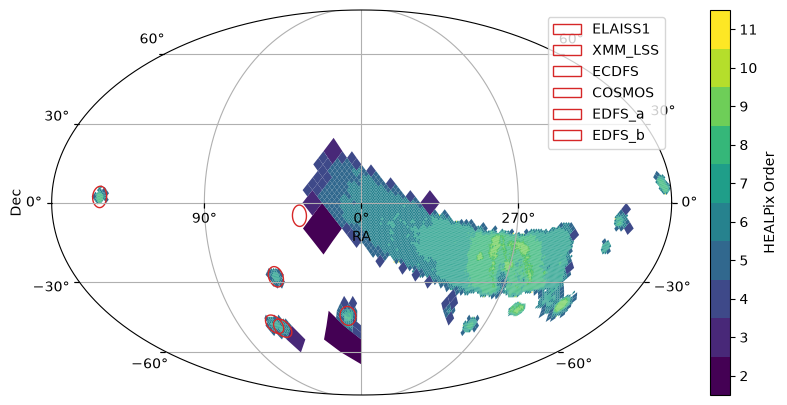

In [10]:
dia_object = lsdb.open_catalog(dia_object_path,
                               columns=["diaObjectId"])
fig, ax = dia_object.plot_pixels()
for name, cone in cones.items():
    color, linestyle = field_styles[name]
    cone.plot(ax=ax, ec=f"tab:{color}", linestyle=linestyle, label=name)
    ax.legend()

(<Figure size 900x500 with 1 Axes>, <WCSAxes: >)

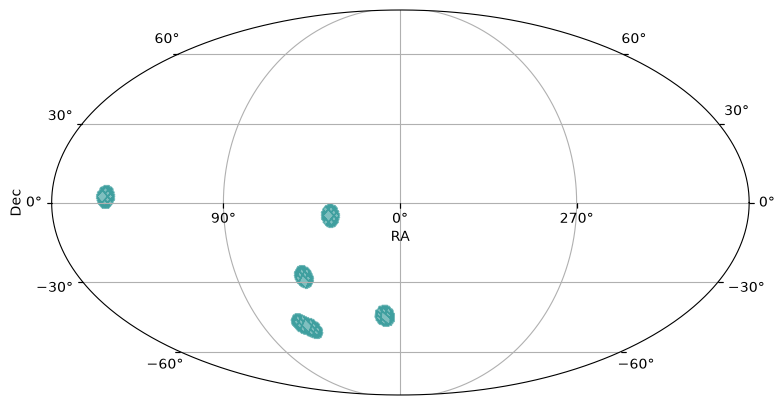

In [11]:
from hats.pixel_math import region_to_moc
from hats.inspection.visualize_catalog import plot_moc

max_depth = dia_object.hc_structure.get_max_coverage_order()

cone_moc_union = region_to_moc.cone_to_moc(ra=next(iter(fields.values()))[0], dec=next(iter(fields.values()))[1], radius_arcsec=radius_arcsec, max_depth=max_depth)
for key, value in list(fields.items())[1:]:
    cone_moc = region_to_moc.cone_to_moc(ra=value[0], dec=value[1], radius_arcsec=radius_arcsec, max_depth=max_depth)
    cone_moc_union = cone_moc_union.union(cone_moc)
plot_moc(cone_moc_union)

In [12]:
# select smaller area
if DDF:
    box = MOCSearch(cone_moc_union)
else:
    # box = lsdb.BoxSearch(ra=[300,360], dec=[-30,0])
    box = None

In [13]:
dia_object = lsdb.open_catalog(dia_object_path,
                               columns=["diaObjectId",
                                        "diaObjectForcedSource.midpointMjdTai","diaObjectForcedSource.band",
                                        "diaObjectForcedSource.psfDiffFlux","diaObjectForcedSource.psfDiffFluxErr",
                                        "diaObjectForcedSource.psfDiffFlux_flag","diaObjectForcedSource.invalidPsfFlag",
                                        "diaSource.midpointMjdTai","diaSource.band",
                                        "diaSource.psfFlux","diaSource.psfFluxErr",
                                        "diaSource.templateFlux","diaSource.templateFluxErr",
                                        "diaSource.reliability","diaSource.psfFlux_flag"], 
                               search_filter=box)

In [14]:
if not DESI:
    objects = lsdb.open_catalog(object_path,columns=["refExtendedness","refSizeExtendedness","objectId"], search_filter=box)
    galaxies = objects.query("refExtendedness > 0.7 & refSizeExtendedness > 0.7")
else:
    objects = lsdb.open_catalog(ls_path,columns=ls_columns, search_filter=box)
    galaxies = objects.query("TYPE != 'PSF'")

In [15]:
objects_around_gal = dia_object.crossmatch(galaxies, radius_arcsec=5, min_radius_arcsec=0.02)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/lsdb/catalog/catalog.py:405: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - dia_object_lc_x_object_lc'}>)

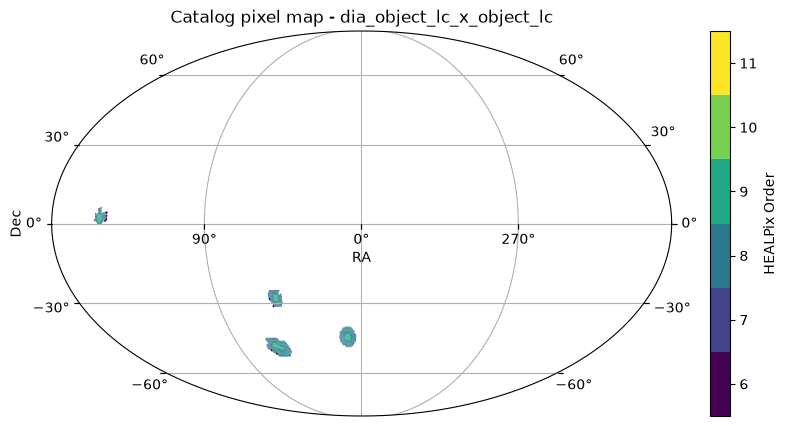

In [16]:
objects_around_gal.plot_pixels()

In [17]:
objects_around_gal = objects_around_gal.query("_dist_arcsec > 0.08 and _dist_arcsec < 5")

In [18]:
objects_around_gal

,diaObjectId_dia_object_lc,ra_dia_object_lc,dec_dia_object_lc,diaObjectForcedSource_dia_object_lc,diaSource_dia_object_lc,refExtendedness_object_lc,refSizeExtendedness_object_lc,objectId_object_lc,coord_ra_object_lc,coord_dec_object_lc,_dist_arcsec
npartitions=5670,,,,,,,,,,,
"Order: 11, Pixel: 27890680",int64[pyarrow],double[pyarrow],double[pyarrow],"nested<midpointMjdTai: [double], band: [string...","nested<midpointMjdTai: [double], band: [string...",float[pyarrow],float[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 7, Pixel: 108950",...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 144545",...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 144546",...,...,...,...,...,...,...,...,...,...,...


In [19]:
def compute_nbands(band):
    nbands = len(np.unique(band))
    n_g = np.sum(band == "g")
    n_r = np.sum(band == "r")
    n_i = np.sum(band == "i")
    n_z = np.sum(band == "z")
    return nbands,n_g,n_r,n_i,n_z

def compute_all_columns(df):    
    cols = ["median_reliability","max_snr",
            "diaSource_dia_object_lc.snr","diaSource_dia_object_lc.flux_diff_ratio",
            "diaSource_dia_object_lc.flux_diff_ratio_abs",
            "median_flux_diff_ratio", "median_flux_diff_ratio_abs",
            "ndet","nbands","n_g","n_r","n_i","n_z","dt"]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in cols})

    else:
        # calculate median reliability
        df = df.map_rows(np.median, columns=["diaSource_dia_object_lc.reliability"], row_container="args", output_names=["median_reliability"], append_columns=True)
    
        # caclulate snr
        df["diaSource_dia_object_lc.snr"] = df["diaSource_dia_object_lc.psfFlux"]/df["diaSource_dia_object_lc.psfFluxErr"]
        
        # calculate max snr
        df = df.map_rows(np.max, columns=["diaSource_dia_object_lc.snr"], row_container="args", output_names=["max_snr"], append_columns=True)
        
        # calculate psfflux difference between template and difference image
        df["diaSource_dia_object_lc.flux_diff_ratio"] = (df["diaSource_dia_object_lc.psfFlux"] - df["diaSource_dia_object_lc.templateFlux"]) / df["diaSource_dia_object_lc.templateFlux"]
        df = df.map_rows(np.absolute, columns=["diaSource_dia_object_lc.flux_diff_ratio"], row_container="args", output_names=["diaSource_dia_object_lc.flux_diff_ratio_abs"], append_columns=True)

        # compute_median_flux_diff_ratio
        df = df.map_rows(np.median, columns=["diaSource_dia_object_lc.flux_diff_ratio"], 
                         row_container="args", output_names=["median_flux_diff_ratio"], append_columns=True)
        df = df.map_rows(np.median, columns=["diaSource_dia_object_lc.flux_diff_ratio_abs"], 
                         row_container="args", output_names=["median_flux_diff_ratio_abs"], append_columns=True)
        
        # calculate number of detections
        df["ndet"] = df["diaSource_dia_object_lc"].len()
        
        # calculate number of bands
        df = df.map_rows(compute_nbands, columns=["diaSource_dia_object_lc.band"], row_container="args",
                         output_names = ["nbands","n_g","n_r","n_i","n_z"],append_columns=True)    
        
        # calculate detection range
        df = df.map_rows(np.ptp, columns=["diaSource_dia_object_lc.midpointMjdTai"], row_container="args", 
                         output_names = ["dt"], append_columns=True)
        # # calculate n per band
        # df = count_nested(df, "diaSource_dia_object_lc", by="band", join=True)
    return df

def filtering(df):
    # # filter reliability
    # df = df.query("median_reliability > 0.5")
            
    # # filter template and diff difference
    # df = df.query("diaSource_dia_object_lc.flux_diff_ratio_abs > 0.2")
    
    df = df.query(
                  # filter n detection
                  "ndet >= 7 and "   
                  # filter maxsnr
                  "max_snr > 10 and "  
                  # filter dt
                  "(dt > 15 and dt < 200) and "
                  # filter nbands
                  "nbands >= 3 and " 
                  # filter n per band
                  "((n_g >= 3) or (n_r >= 3) or (n_i >= 3) or (n_z >= 3))"
                 )
    return df

In [20]:
N_JOBS_PER_WORKER = -1
extractor = licu.Extractor(licu.BazinFit(algorithm='nuts-ceres',bands=["g","r","i","z"]), licu.ReducedChi2(bands=["g","r","i","z"]))
def fitbazin(df):
    df_fit = df.query("diaObjectForcedSource_dia_object_lc.psfDiffFlux_flag == False and "
                  "diaObjectForcedSource_dia_object_lc.invalidPsfFlag == False")
    df_fit = df_fit.query("diaObjectForcedSource_dia_object_lc.band == 'r' or diaObjectForcedSource_dia_object_lc.band == 'i' or "
                      "diaObjectForcedSource_dia_object_lc.band == 'g' or diaObjectForcedSource_dia_object_lc.band == 'z'")
    df_fit["diaObjectForcedSource_dia_object_lc.t"] = (df_fit["diaObjectForcedSource_dia_object_lc.midpointMjdTai"] - 60000).astype(np.float32)
    if len(df_fit) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in extractor.names})
    else:
        features = extractor.many(pa.array(df_fit["diaObjectForcedSource_dia_object_lc"]), 
                                    arrow_fields={"t": "t", "m": "psfDiffFlux", "sigma": "psfDiffFluxErr","band":"band"},
                                    n_jobs=N_JOBS_PER_WORKER, fill_value=np.nan)  # default -1 which uses all the CPU cores
        df = df.assign(**(dict(zip(extractor.names, features.T))))
    return df

In [21]:
objects_around_gal = objects_around_gal.map_partitions(compute_all_columns)

In [22]:
# objects_around_gal.head()

In [23]:
filtered = objects_around_gal.map_partitions(filtering)

In [24]:
# head = filtered.head()
# head

In [25]:
bazin = filtered.map_partitions(fitbazin)

In [26]:
if DDF:
    outname = "sncandid_w_bazin_ddf"
else:
    outname = "sncandid_w_bazin"
if DESI:
    outname = outname+"_desi_gal"
bazin.write_catalog(outname, overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 20.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
E20260716 22:01:06.667654 541120 trust_region_minimizer.cc:121] Terminating: Residual and Jacobian evaluation failed.
E20260716 22:01:06.896859 541403 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260716 22:01:07.033185 541657 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260716 22:01:07.033249 541657 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260716 22:01:07.033274 541657 program_evaluator.h:286] Accumulated cost = i

In [27]:
client.close()